<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_initial_2class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Field validation test and analyse 1s 30hz

In [ ]:
# Author: Ziyi Liu
# Project: Bachelor's Thesis - Cyclist Curb Detection under Varying Road Roughness
# Institution: Universität Kassel
# License: GNU General Public License v3.0

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *
from utils.analyse import *

## 1. Load data

In [27]:
with open('../../data/Field_validation/segmented_data_30hz.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

segments = loaded_data['segments']
segments.shape




(2496, 30, 3)

In [28]:
with open('../../data/Field_validation/segmented_labels_30hz.pkl', 'rb') as f:
    segment_info = pickle.load(f)  # file stores the list directly
len(segment_info)


2496

In [29]:
df_segments_info = pd.DataFrame(segment_info)
df_segments_info.head(10)

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
0,0,2025-10-21 15:15:40.347,2025-10-21 15:15:41.304,0,0.0,0.0
1,1,2025-10-21 15:15:41.337,2025-10-21 15:15:42.294,30,0.0,0.0
2,2,2025-10-21 15:15:42.327,2025-10-21 15:15:43.284,60,0.0,0.0
3,3,2025-10-21 15:15:43.317,2025-10-21 15:15:44.274,90,0.0,0.0
4,4,2025-10-21 15:15:44.307,2025-10-21 15:15:45.264,120,0.0,0.0
5,5,2025-10-21 15:15:45.297,2025-10-21 15:15:46.254,150,0.0,0.0
6,6,2025-10-21 15:15:46.287,2025-10-21 15:15:47.244,180,0.0,0.0
7,7,2025-10-21 15:15:47.277,2025-10-21 15:15:48.234,210,0.0,0.0
8,8,2025-10-21 15:15:48.267,2025-10-21 15:15:49.224,240,0.0,0.0
9,9,2025-10-21 15:15:49.257,2025-10-21 15:15:50.214,270,0.0,0.0


In [30]:
df_segments_info.iloc[868:876]

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
868,868,2025-10-21 15:29:59.667,2025-10-21 15:30:00.624,26040,0.0,1.0
869,869,2025-10-21 15:30:00.657,2025-10-21 15:30:01.614,26070,0.0,1.0
870,870,2025-10-21 15:30:01.647,2025-10-21 15:30:02.604,26100,0.0,1.0
871,871,2025-10-21 15:30:02.637,2025-10-21 15:30:03.594,26130,0.0,1.0
872,872,2025-10-21 15:30:03.627,2025-10-21 15:30:04.584,26160,0.0,1.0
873,873,2025-10-21 15:30:04.617,2025-10-21 15:30:05.574,26190,0.0,1.0
874,874,2025-10-21 15:30:05.607,2025-10-21 15:30:06.564,26220,0.0,1.0
875,875,2025-10-21 15:30:06.597,2025-10-21 15:30:07.554,26250,0.0,1.0


In [31]:
# Extract curb_scene labels from segment_info
labels = np.array([info['curb_scene'] for info in segment_info])

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")


Labels shape: (2496,)
Unique labels: [0. 1.]


In [32]:
# Convert labels to one-hot encoding
labels_one_hot = to_categorical(labels, num_classes=2)

print(f"Original labels shape: {labels.shape}")
print(f"One-hot labels shape: {labels_one_hot.shape}")
print(f"First 5 original labels: {labels[:5]}")
print(f"First 5 one-hot labels:\n{labels_one_hot[:5]}")

Original labels shape: (2496,)
One-hot labels shape: (2496, 2)
First 5 original labels: [0. 0. 0. 0. 0.]
First 5 one-hot labels:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [33]:
# Normalize segments
data_normalized = normalize_3d_data(segments)

## 2.Load model and evaluate

### a)real world model

11/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


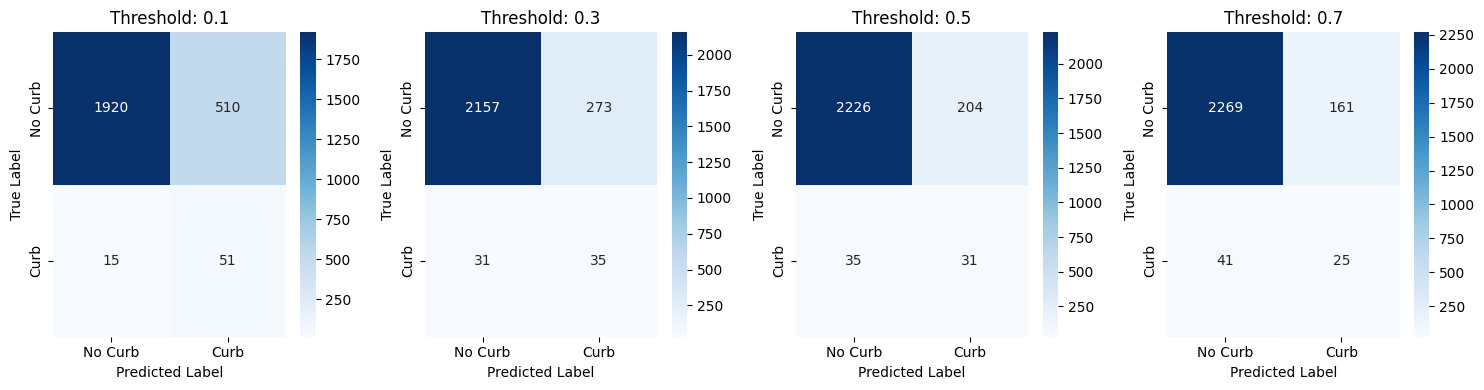


Summary Comparison
Threshold 0.1: Accuracy=0.7897, Precision=0.0909, Recall=0.7727
Threshold 0.3: Accuracy=0.8782, Precision=0.1136, Recall=0.5303
Threshold 0.5: Accuracy=0.9042, Precision=0.1319, Recall=0.4697
Threshold 0.7: Accuracy=0.9191, Precision=0.1344, Recall=0.3788


In [37]:
# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_linear_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Get predictions
predictions = full_eval_best_model.predict(data_normalized)

# Test different thresholds
thresholds = [0.1,0.3, 0.5, 0.7]
results = {}

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    # Convert predictions to binary labels using threshold
    binary_predictions = (predictions[:, 1] >= threshold).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(labels, binary_predictions)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results[threshold] = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Curb', 'Curb'],
                yticklabels=['No Curb', 'Curb'])
    axes[idx].set_title(f'Threshold: {threshold}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*50}")
print("Summary Comparison")
print(f"{'='*50}")
for threshold in thresholds:
    print(f"Threshold {threshold}: Accuracy={results[threshold]['accuracy']:.4f}, Precision={results[threshold]['precision']:.4f}, Recall={results[threshold]['recall']:.4f}")

### b.Load pseudo model and evaluate

14/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


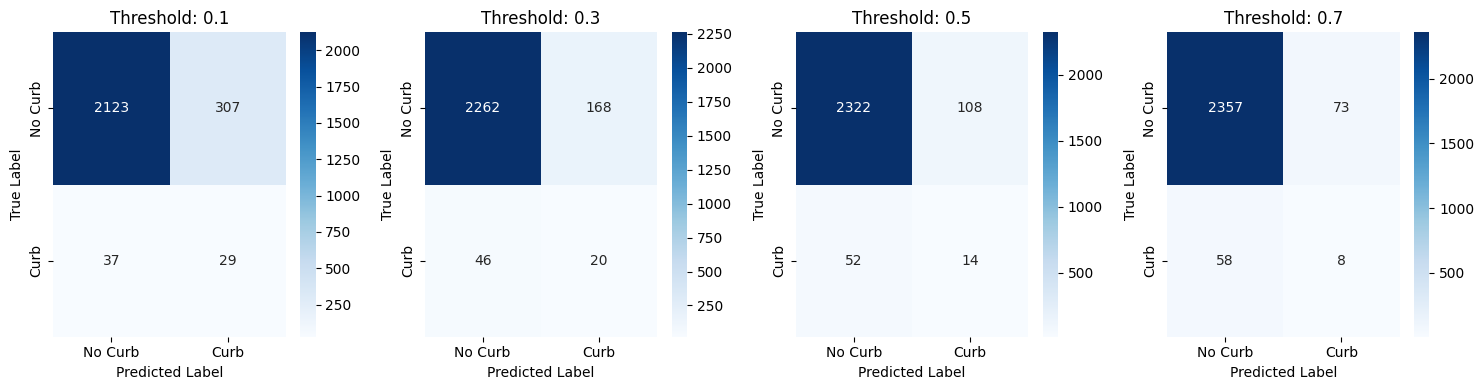


Summary Comparison
Threshold 0.1: Accuracy=0.8622, Precision=0.0863, Recall=0.4394
Threshold 0.3: Accuracy=0.9143, Precision=0.1064, Recall=0.3030
Threshold 0.5: Accuracy=0.9359, Precision=0.1148, Recall=0.2121
Threshold 0.7: Accuracy=0.9475, Precision=0.0988, Recall=0.1212


In [40]:
# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_30hz/2class_unbalanced_real_world_a_with_pseudo/20251211-132503_simclr_full_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Get predictions
predictions = full_eval_best_model.predict(data_normalized)

# Test different thresholds
thresholds = [0.1,0.3, 0.5, 0.7]
results = {}

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    # Convert predictions to binary labels using threshold
    binary_predictions = (predictions[:, 1] >= threshold).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(labels, binary_predictions)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results[threshold] = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Curb', 'Curb'],
                yticklabels=['No Curb', 'Curb'])
    axes[idx].set_title(f'Threshold: {threshold}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*50}")
print("Summary Comparison")
print(f"{'='*50}")
for threshold in thresholds:
    print(f"Threshold {threshold}: Accuracy={results[threshold]['accuracy']:.4f}, Precision={results[threshold]['precision']:.4f}, Recall={results[threshold]['recall']:.4f}")

## 3. Analyses

In [9]:
# Create a detailed DataFrame for all segments with predictions and segment info
all_segments_details = []

for idx in range(len(labels)):
    segment_detail = {
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    }
    
    all_segments_details.append(segment_detail)

# Convert to DataFrame
df_all_segments = pd.DataFrame(all_segments_details)

# Display the DataFrame
print(f"Total segments: {len(df_all_segments)}")
print(f"\nDataFrame shape: {df_all_segments.shape}")
print(f"\nColumns: {df_all_segments.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_all_segments.head(10))

# # Save to CSV
# df_all_segments.to_csv('../../data/Field_validation/all_segments_with_predictions_30hz.csv', index=False)

Total segments: 2496

DataFrame shape: (2496, 7)

Columns: ['Index', 'True Label', 'Predicted Label', 'Prediction Score (Class 0)', 'Prediction Score (Class 1)', 'Start Time', 'End Time']

First 10 rows:
   Index  True Label  Predicted Label  Prediction Score (Class 0)  \
0      0         0.0                0                    0.978082   
1      1         0.0                0                    0.973896   
2      2         0.0                0                    0.987328   
3      3         0.0                0                    0.984247   
4      4         0.0                0                    0.962545   
5      5         0.0                0                    0.971850   
6      6         0.0                0                    0.969941   
7      7         0.0                0                    0.974061   
8      8         0.0                0                    0.973594   
9      9         0.0                0                    0.970153   

   Prediction Score (Class 1)       

Number of False Positives: 280

False Positive Indices:
[  73   74  105  107  168  213  256  276  284  286  293  297  299  344
  345  354  358  362  363  488  629  640  666  700  764  868  869  870
  871  872  874  875  950 1045 1114 1115 1116 1121 1148 1155 1158 1220
 1221 1222 1223 1226 1228 1229 1232 1233 1234 1235 1238 1239 1240 1241
 1242 1245 1246 1291 1371 1373 1375 1376 1382 1383 1384 1385 1386 1387
 1388 1390 1391 1392 1393 1394 1395 1396 1397 1399 1400 1401 1402 1403
 1404 1407 1408 1409 1410 1411 1412 1414 1415 1417 1418 1419 1441 1472
 1498 1499 1500 1501 1512 1532 1536 1537 1542 1545 1546 1549 1579 1580
 1581 1582 1589 1590 1591 1592 1593 1594 1600 1605 1606 1607 1645 1688
 1691 1708 1716 1738 1740 1748 1749 1750 1774 1797 1798 1799 1813 1862
 1863 1867 1868 1869 1915 1916 1917 1918 1919 1920 1921 1922 1923 1924
 1965 1966 1967 1968 1970 1971 1973 1974 1975 1976 1995 1998 1999 2010
 2100 2132 2186 2189 2190 2191 2192 2193 2195 2196 2197 2198 2199 2200
 2201 2202 2203 2204 

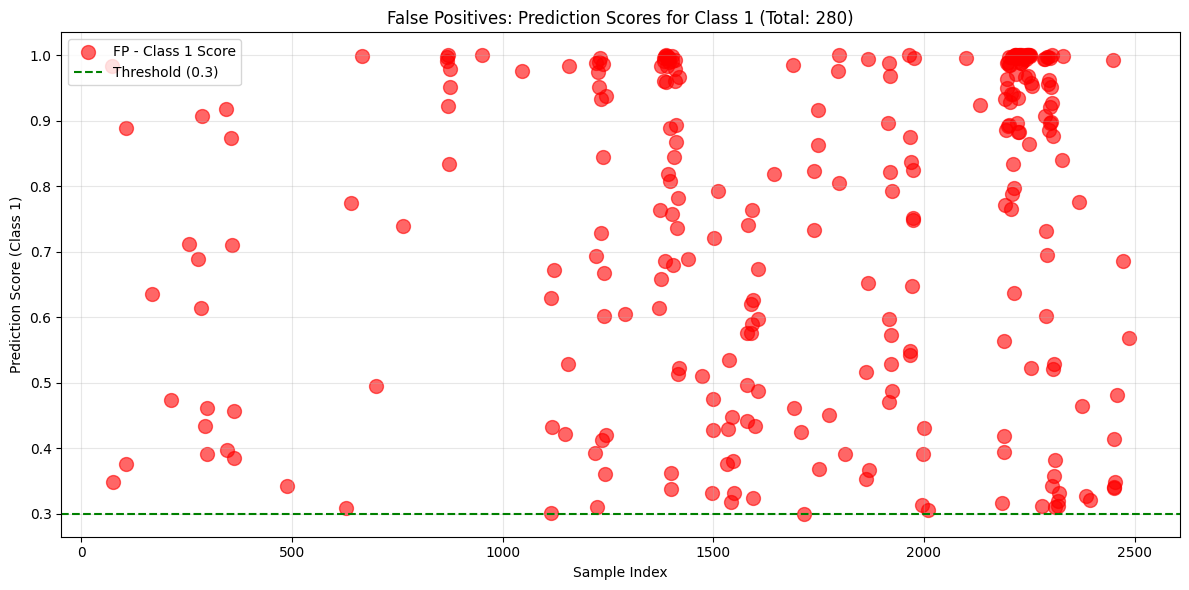

In [10]:
# Use threshold 0.5 (you can change this)
threshold = 0.3
binary_predictions = (predictions[:, 1] >= threshold).astype(int)

# # Find False Negatives: True label is 1, but predicted as 0
# fn_indices = np.where((labels == 1) & (binary_predictions == 0))[0]
# # Find True Positives: True label is 1, but predicted as 1
# tp_indices = np.where((labels == 1) & (binary_predictions == 1))[0]
# Find False Positives: True label is 0, but predicted as 1
fp_indices = np.where((labels == 0) & (binary_predictions == 1))[0]

print(f"Number of False Positives: {len(fp_indices)}")
print(f"\nFalse Positive Indices:")
print(fp_indices)

# Create a detailed DataFrame for False Positives
fp_details = []
for idx in fp_indices:
    fp_details.append({
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    })

fp_df = pd.DataFrame(fp_details)
print(f"\nDetailed False Positive Information:")
print(fp_df)

# Visualize prediction scores for False Positives
plt.figure(figsize=(12, 6))
plt.scatter(fp_indices, predictions[fp_indices, 1], c='red', label='FP - Class 1 Score', alpha=0.6, s=100)
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Score (Class 1)')
plt.title(f'False Positives: Prediction Scores for Class 1 (Total: {len(fp_indices)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save as CSV
fp_df.to_csv('../../data/Field_validation/false_positives_30hz.csv', index=False)

In [ ]:
# Save to CSV
predictions_df.to_csv('../../data/Field_validation/predictions_30hz_threshold_0.1.csv', index=False)
print(f"Saved predictions with threshold 0.1 to: ../../data/Field_validation/predictions_30hz_threshold_0.1.csv")

In [11]:
df_video = pd.read_csv('../../data/Field_validation/raw_data/video.csv')
df_video.head()

,NTP,Timestamp,Video,X,Y,Z
0,"2025-10-21, 15:15:42.0410","2025-10-21, 15:15:42.0390",00:00:00.104,-0.161850,-0.621307,-0.760971
1,"2025-10-21, 15:15:42.0420","2025-10-21, 15:15:42.0410",00:00:00.105,-0.166687,-0.623611,-0.760941
2,"2025-10-21, 15:15:42.0490","2025-10-21, 15:15:42.0480",00:00:00.112,-0.161774,-0.620071,-0.765106
3,"2025-10-21, 15:15:42.0520","2025-10-21, 15:15:42.0500",00:00:00.114,-0.156738,-0.621979,-0.765808
4,"2025-10-21, 15:15:42.0530","2025-10-21, 15:15:42.0520",00:00:00.116,-0.152634,-0.622070,-0.766769


In [13]:
# get video positions for each false negative
fp_df = match_false_negatives_to_video(fp_df, df_video, buffer_seconds=0.1)
print(fp_df[['Index', 'Start Time', 'video', 'matched_ntp', 'time_diff']])

c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:01:10.679' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'video'] = best['Video']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-10-21 15:16:52.617000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'matched_ntp'] = best['NTP']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Va

     Index              Start Time         video                 matched_ntp  \
0       73 2025-10-21 15:16:52.617  00:01:10.679  2025-10-21 15:16:52.617000   
1       74 2025-10-21 15:16:53.607  00:01:11.666  2025-10-21 15:16:53.603000   
2      105 2025-10-21 15:17:24.297  00:01:42.356  2025-10-21 15:17:24.294000   
3      107 2025-10-21 15:17:26.277  00:01:44.339  2025-10-21 15:17:26.277000   
4      168 2025-10-21 15:18:26.667  00:02:44.724  2025-10-21 15:18:26.662000   
..     ...                     ...           ...                         ...   
275   2452 2025-10-21 15:56:07.827  00:40:25.892  2025-10-21 15:56:07.829000   
276   2453 2025-10-21 15:56:08.817  00:40:26.878  2025-10-21 15:56:08.816000   
277   2459 2025-10-21 15:56:14.757  00:40:32.816  2025-10-21 15:56:14.754000   
278   2472 2025-10-21 15:56:27.627  00:40:45.689  2025-10-21 15:56:27.626000   
279   2487 2025-10-21 15:56:42.477  00:41:00.534  2025-10-21 15:56:42.472000   

                  time_diff  
0        

In [ ]:
fp_df.to_csv('../../data/Field_validation/false_positives_30hz_with_video.csv', index=False)

## 4. Relabeling

In [ ]:
# Indices to relabel
fix_indices = np.arange(868, 876)  # 868–875 inclusive

# Apply relabel to labels array
labels[fix_indices] = 1

# Update segment_info entries
for i in fix_indices:
    segment_info[i]['curb_scene'] = int(1)

with open('../../data/Field_validation/segmented_data_30hz.pkl', 'wb') as f:
    pickle.dump(segment_info, f)
# fehlt noch data itself



In [14]:
len(segment_info)

2496

## Extra: t-SNE Plots

In [10]:
import sklearn.manifold
import seaborn as sns

In [11]:
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(full_eval_best_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(data_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "TPN_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 49,248 (192.38 KB)

 Non-trainable params: 35,168 (137.38 KB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2496 samples in 0.000s...


c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[t-SNE] Computed neighbors for 2496 samples in 0.427s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2496
[t-SNE] Computed conditional probabilities for sample 2000 / 2496
[t-SNE] Computed conditional probabilities for sample 2496 / 2496
[t-SNE] Mean sigma: 0.537842
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.892639
[t-SNE] KL divergence after 1000 iterations: 1.122641


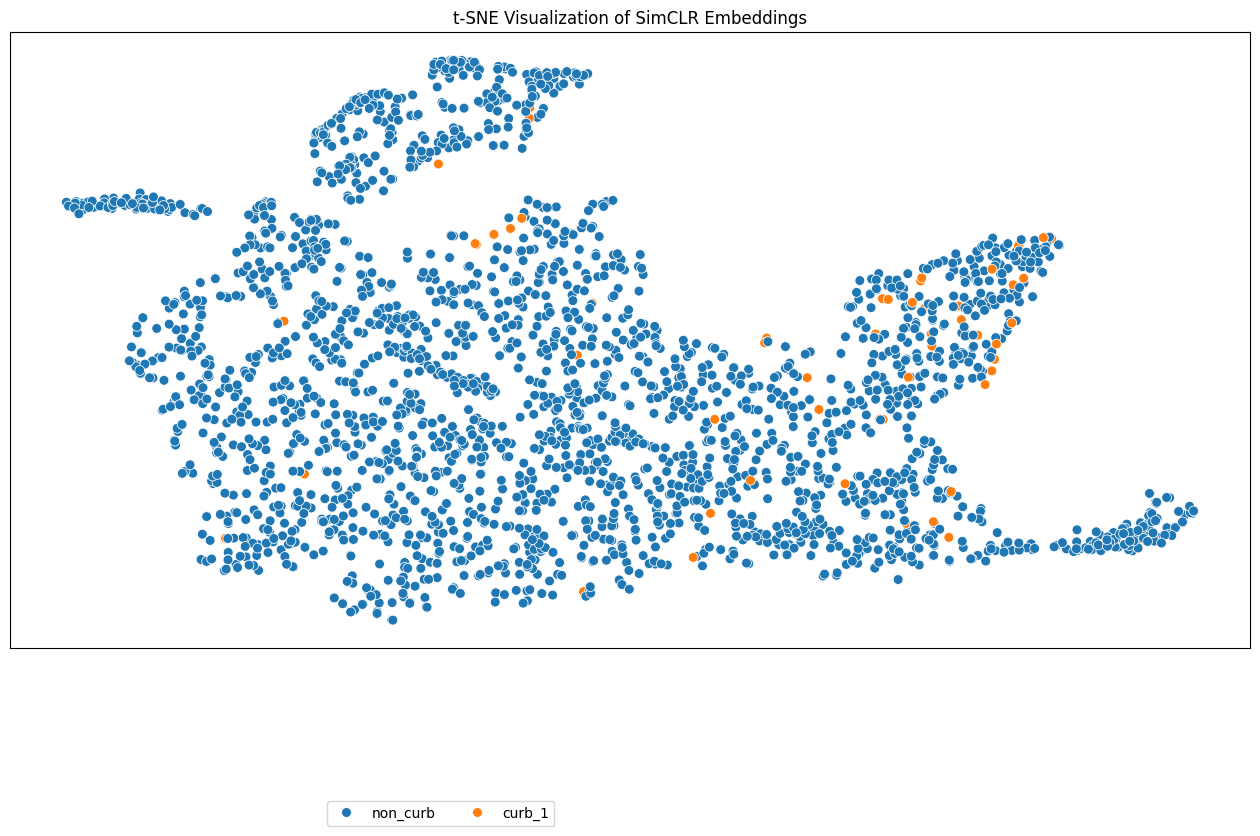

In [12]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(labels_one_hot, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)